In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import colormaps as cmaps


import bz2
import _pickle as cPickle

In [2]:
def load_compressed_pickle(filename):    
    data = bz2.BZ2File(filename + '.pbz2', 'rb')
    data = cPickle.load(data)
    return data

# Figure 1

### Dynamics

In [3]:
dynamics = np.load("../data/figures/fig1/CR_dynamics.npz")
solution = dynamics["usol"]
t = dynamics["t"]

In [4]:
color_palette = ["#0466c8","#0353a4","#023e7d","#002855","#001845","#001233","#33415c","#5c677d","#7d8597","#979dac"]
max_color_palette = ["#de7da2","#478141ff","#40a2dbff","#af2f2dff"]
color_palette = np.array([
"#ffb14e",
"#fa8775",
"#ffd700",
"#010195",
"#ea5f94",
"#cd34b5",
"#9d02d7"])

color_palette = color_palette[np.random.permutation(len(color_palette))]

In [5]:
max_species = np.argsort(solution[-1,:10])[::-1][:4]

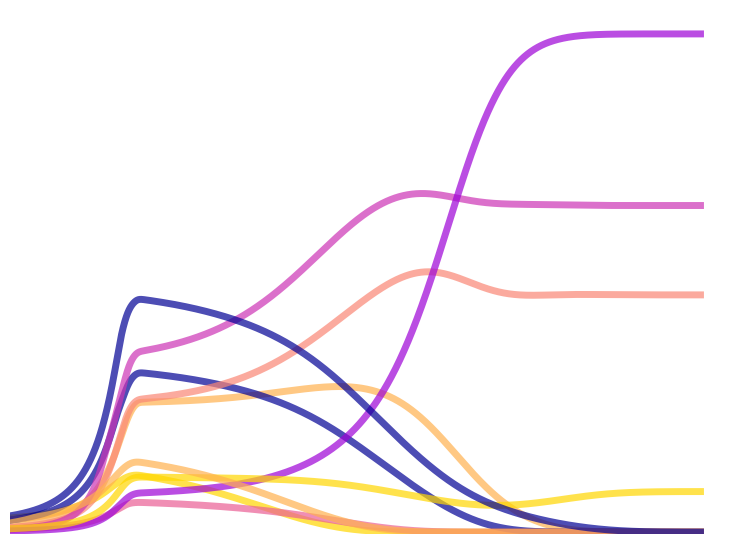

In [6]:
plt.rcParams.update({'font.size': 25,"axes.linewidth": 0})
fig,ax = plt.subplots(figsize=(8, 6))
for i in range(10):
    plt.plot(t,solution[:,i],lw=5,color=color_palette[i%len(color_palette)],alpha=0.7)
# for i in range(4):
#     plt.plot(t,solution[:,max_species[i]],color=max_color_palette[i%len(max_color_palette)],linewidth=4)
plt.xscale("log")
plt.xlim(1,)
plt.ylim(-1,)
plt.xticks([],[])
plt.yticks([],[])
plt.minorticks_off()

ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
# plt.savefig("../figures/generated/fig1/dynamics.svg",dpi=200,bbox_inches="tight")
plt.show()

### Interactions (schematic)

In [7]:
interactions = np.load("../data/figures/fig1/CR_interactions.npy")
non_diag_interactions = interactions[~np.eye(interactions.shape[0],dtype=bool)]

In [8]:
gauss_mean,gauss_std = np.mean(non_diag_interactions),np.std(non_diag_interactions)
lognormal_mean,lognormal_std = np.mean(np.log(non_diag_interactions)),np.std(np.log(non_diag_interactions))

In [9]:
hist,edges = np.histogram(-non_diag_interactions,bins=100,range=(-1.5,1.),density=True)

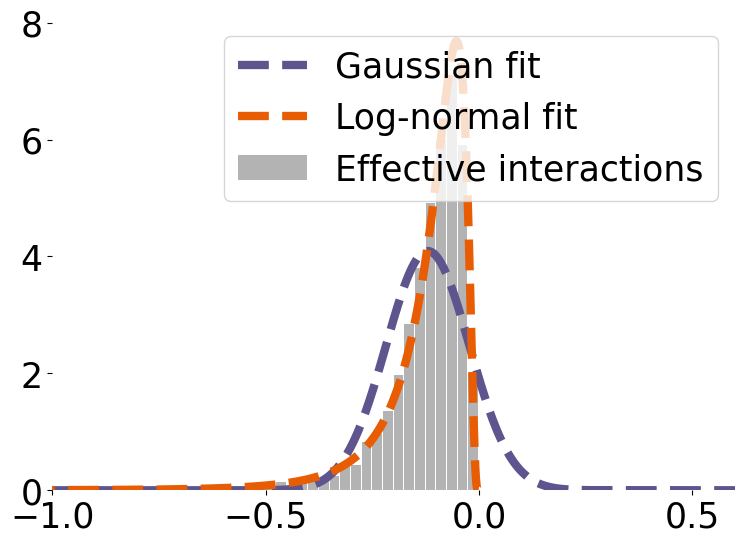

In [10]:
fig,ax = plt.subplots(figsize=(8, 6))
ax.bar(edges[:-1],hist,width=np.diff(edges)*0.9,align='edge',facecolor="#696969",alpha=0.5,label="Effective interactions")

lognormal_range = np.linspace(0.001,1.5,1000)
gaussian_range = np.linspace(-1.5,1.5,1000)

ax.plot(-gaussian_range,1/(gauss_std*np.sqrt(2*np.pi))*np.exp(-((gaussian_range-gauss_mean)**2)/(2*gauss_std**2)),lw=6,label="Gaussian fit",ls="--",color="#5e548e")
ax.plot(-lognormal_range,np.exp(-((np.log(lognormal_range)-lognormal_mean)**2)/(2*lognormal_std**2))/(lognormal_range*lognormal_std*np.sqrt(2*np.pi)),lw=6,ls="--",label="Log-normal fit",color="#e85d04")
plt.xlim(-1,.6)
# plt.ylim(0,1.5)
# plt.xlabel("Interaction strength")
# plt.ylabel("Density")
plt.legend()
ax.spines[["top","right"]].set_visible(False) 
plt.tight_layout()
# plt.savefig("../figures/generated/fig1/interaction_concept.svg",dpi=100,bbox_inches="tight")
plt.show()

### Skewness boxplot

In [11]:
interaction_measures = np.load("../data/figures/fig1/interaction_measures.npy")

In [12]:
skew_values = interaction_measures[:,:,2].flatten()

In [13]:
stats.wilcoxon(skew_values)

WilcoxonResult(statistic=6170.0, pvalue=2.940625566071811e-157)

In [16]:
import ptitprince as pt

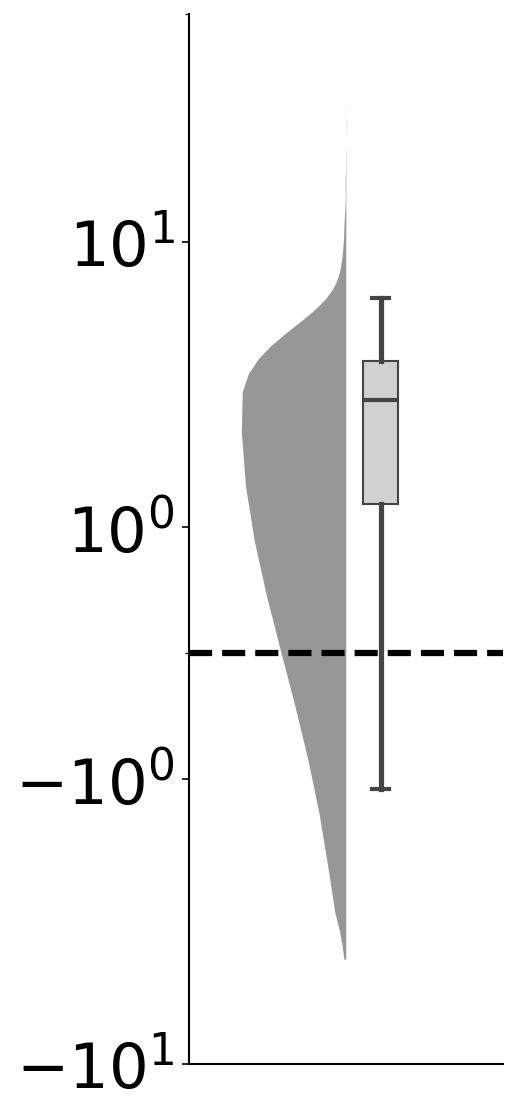

In [17]:
dy = skew_values
ort = "v"

fig,ax = plt.subplots(figsize=(4,8),dpi=150)

ax = pt.half_violinplot(x=1,y = skew_values,bw=0.5,
    cut=0.0,
    scale="area",
    width=0.6,
    orient="v",
    color="#979797",
    linewidth=0
)
bp = plt.boxplot(skew_values,bootstrap=10000,showfliers=False,patch_artist=True,
                    capprops={'linewidth':2,'color':"#444444"},whiskerprops={'linewidth':2.5,'color':"#444444"},medianprops={'linewidth':2,'color':'#444444'},boxprops={'edgecolor':'#444444','facecolor':"#D1D1D1",'alpha':1},widths=0.1,positions=[-0.05],zorder=5)

plt.yscale("symlog",linthresh=2)
plt.xticks([],[])
plt.yticks([-10,-1,1,10],fontsize=30)
plt.ylim(-10,100)
plt.xlim(-0.6,0.3)
plt.axhline(0,color='black',linewidth=3,linestyle='--',label="Gaussian")
for axis in ['left', 'bottom']:
    ax.spines[axis].set_linewidth(1)
plt.tight_layout()

# plt.savefig("../figures/generated/fig1/skewness_raincloud.svg",dpi=200,bbox_inches="tight")
plt.show()

### Interactions (simulations)

In [18]:
interactions_cv_10 = np.load("../data/figures/fig2/new_rescaled_interactions_N-cv-10.npz")
rescaled_interaction_matrices_cv_10 = interactions_cv_10["rescaled_interaction_matrices"]

interactions_cv_1 = np.load("../data/figures/fig2/new_rescaled_interactions_N-cv-1.npz")
rescaled_interaction_matrices_cv_1 = interactions_cv_1["rescaled_interaction_matrices"]

In [19]:
def compute_hists(cur_int):
    non_diag_int = cur_int[~np.eye(cur_int.shape[0],dtype=bool)]
    print(stats.skew(non_diag_int))
    hist,edges = np.histogram(-non_diag_int,bins=200,range=(-1.5,1.5),density=True)
    mean,sd = np.mean(non_diag_int),np.std(non_diag_int)
    return hist,edges,mean,sd

In [20]:
hists,edges = [],[]
gaussian_params = []

for i in range(3):
    cur_int_10 = rescaled_interaction_matrices_cv_10[i,0,:,:]
    cur_int_1 = rescaled_interaction_matrices_cv_1[i,0,:,:]
    print(i)
    hist_10,edges_10,mean_10,sd_10 = compute_hists(cur_int_10)
    hist_1,edges_1,mean_1,sd_1 = compute_hists(cur_int_1)
    hists.append((hist_1,hist_10))
    edges.append((edges_1,edges_10))
    gaussian_params.append((mean_1,sd_1))
    gaussian_params.append((mean_10,sd_10))

0
3.4158260038332138
-0.015194524680957867
1
9.468923924410188
0.0818412720066964
2
11.186417284096112
0.2419040871613853


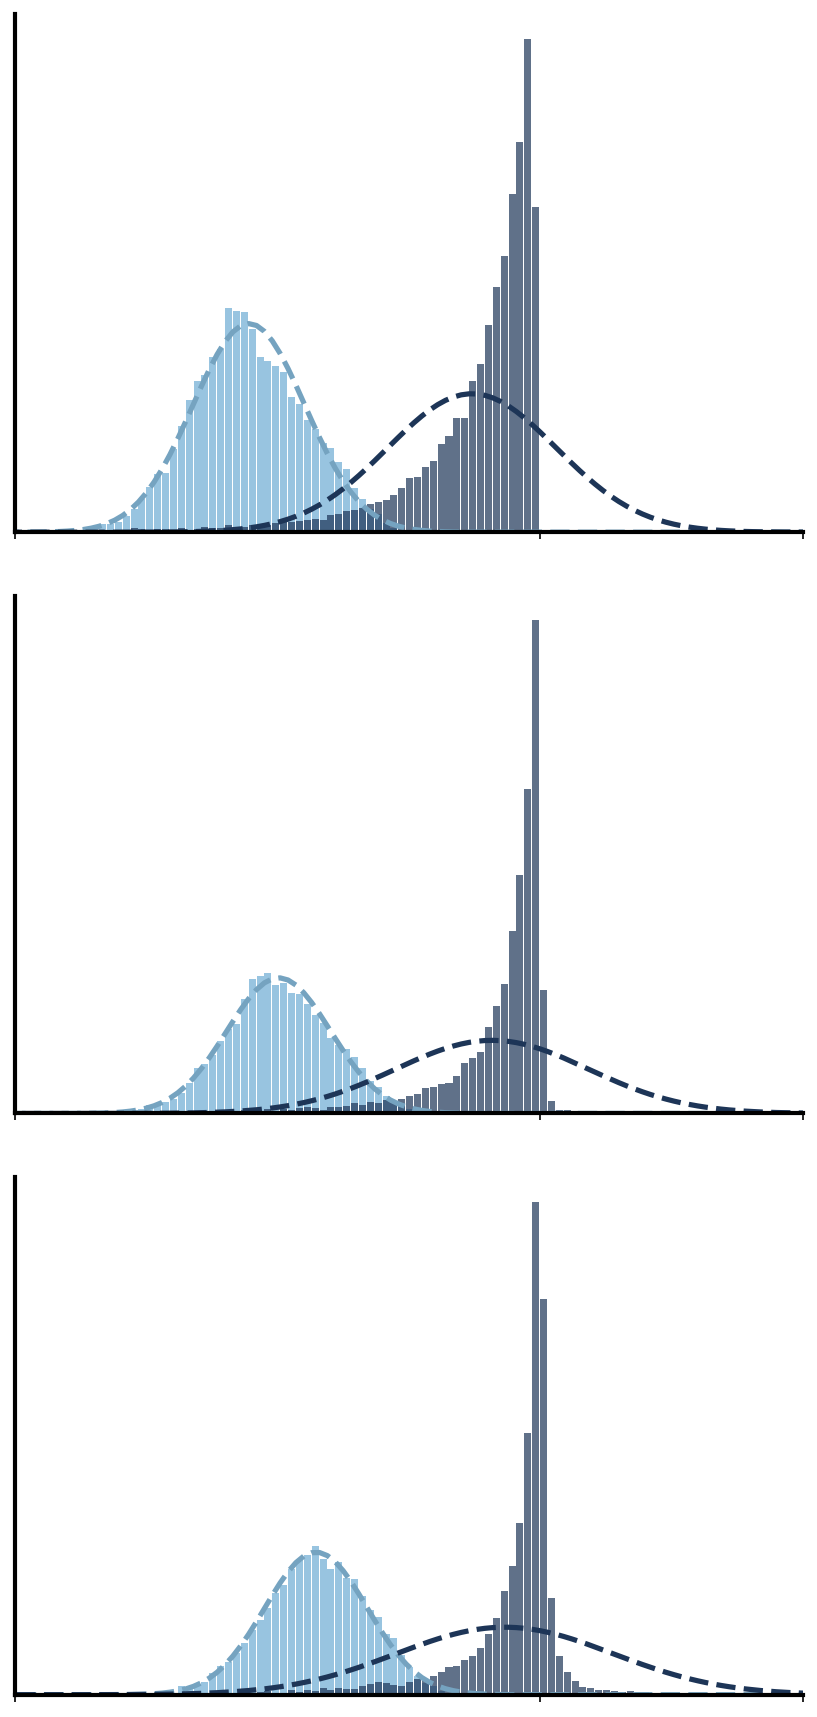

In [21]:
fig,ax = plt.subplots(3,1,figsize=(6, 12),dpi=150,sharex=False,sharey=False)

for i in range(3):
    ax[i].bar(edges[i][0][:-1],hists[i][0],width=np.diff(edges[i][0])*0.9,align='edge',facecolor="#6cacd3",alpha=0.7,label="CV=1")
    ax[i].bar(edges[i][1][:-1],hists[i][1],width=np.diff(edges[i][1])*0.9,align='edge',facecolor="#1d3557",alpha=0.7,label="CV=10")
    ax[i].plot(-edges[i][0],1/(gaussian_params[2*i][1]*np.sqrt(2*np.pi))*np.exp(-((edges[i][0]-gaussian_params[2*i][0])**2)/(2*gaussian_params[2*i][1]**2)),lw=2.5,ls="--",color="#75a3c0")
    ax[i].plot(-edges[i][1],1/(gaussian_params[2*i+1][1]*np.sqrt(2*np.pi))*np.exp(-((edges[i][1]-gaussian_params[2*i+1][0])**2)/(2*gaussian_params[2*i+1][1]**2)),lw=2.5,ls="--",color="#1d3557")
    ax[i].set_xlim(-1.,.5)
    ax[i].set_xticks([-1,0,0.5],[])
    ax[i].set_yticks([],[])
    for axis in ['left', 'bottom']:
        ax[i].spines[axis].set_linewidth(2)   
plt.tight_layout()
# plt.savefig("../figures/generated/fig1/interactions_histograms.svg",dpi=150,bbox_inches="tight")
plt.show()


### Drivers of skewness

In [22]:
def compute_skew(cumulants):
    skew = np.mean(cumulants[:,:, 2] / cumulants[:, :,1]**(3/2),axis=1)
    return skew -skew[0]

In [28]:
competitive_skew_data = np.load("../data/figures/fig2/competitive_skew.npy",allow_pickle=True).item()
comp_theory_sd = competitive_skew_data["theory_sd_mu"]
comp_theory_cumulants = competitive_skew_data["theory_cumulants"]
comp_simul_sd = competitive_skew_data["sd_mu"]
comp_simul_cumulants = competitive_skew_data["simulation_cumulants"]

theory_comp_skew = compute_skew(comp_theory_cumulants)
simul_comp_skew = compute_skew(comp_simul_cumulants)

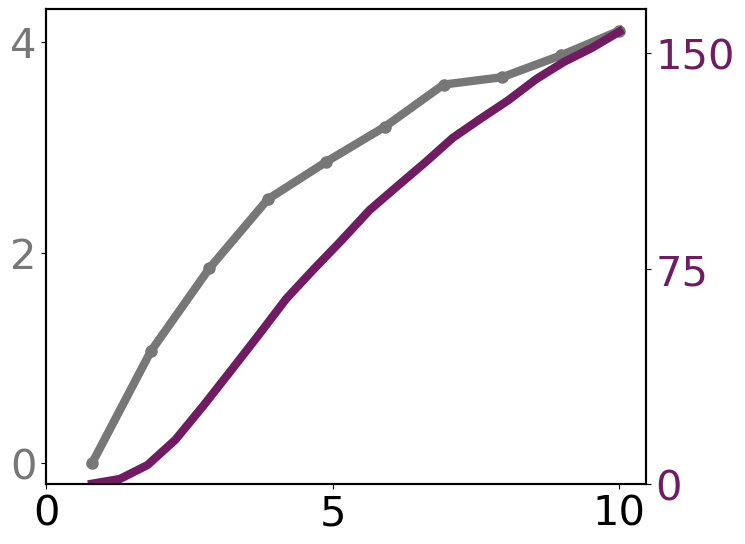

In [30]:
plt.rcParams.update({'font.size': 25,"axes.linewidth": 1.5})
fig,ax1 = plt.subplots(figsize=(8, 6))

plt.gca().spines['right'].set_visible(True)

ax1.plot(comp_simul_sd, simul_comp_skew, lw=6,marker="o",markersize=8, color="#777777")
ax1.set_xlim(0.,)
ax1.set_ylim(-0.2,)
ax1.set_yticks([0,2,4])
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30,labelcolor="#777777")

ax2 = ax1.twinx()
ax2.plot(comp_theory_sd, theory_comp_skew, lw=6, color="#711c62")
ax2.set_ylim(-0.2,)
ax2.tick_params(axis='y', labelsize=30,labelcolor="#711c62")
ax2.set_yticks([0,75,150])

fig.tight_layout()
plt.show()


In [31]:
crossfeeding_skew_data = np.load("../data/figures/fig2/crossfeeding_skew.npy",allow_pickle=True).item()

In [32]:
simul_lmin_vals = crossfeeding_skew_data["lMinVals"]
simul_lmax_vals = crossfeeding_skew_data["lMaxVals"]
simul_leak_vals = (simul_lmin_vals + simul_lmax_vals) / 2
simul_cf_cumulants = crossfeeding_skew_data["simulation_cumulants"]

crossfeeding_theory_skew = np.load("../data/figures/fig2/crossfeeding_theory_skew.npy",allow_pickle=True).item()
theory_lvals = crossfeeding_theory_skew["lValues"]
theory_cf_cumulants = crossfeeding_theory_skew["theory_cumulants"]

simul_cf_skew = compute_skew(simul_cf_cumulants)
theory_cf_skew = compute_skew(theory_cf_cumulants)

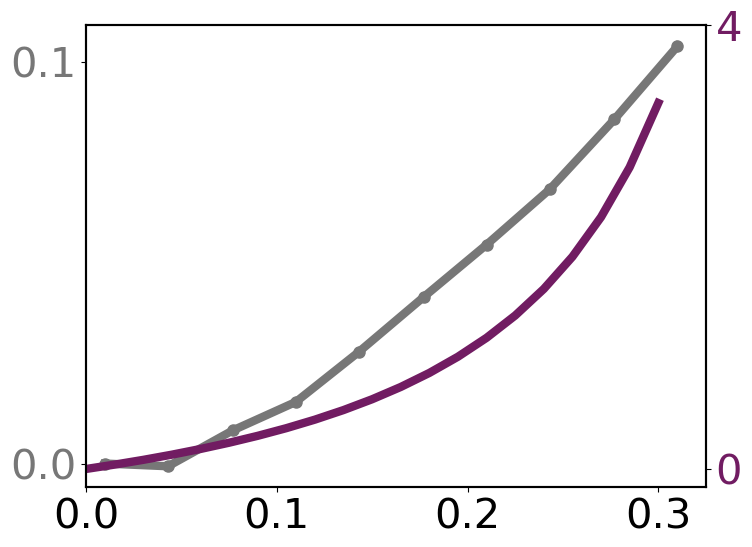

In [33]:
plt.rcParams.update({'font.size': 25,"axes.linewidth": 1.5})
fig,ax1 = plt.subplots(figsize=(8, 6))

plt.gca().spines['right'].set_visible(True)

ax1.plot(simul_leak_vals,simul_cf_skew,lw=6,marker="o",markersize=8, color="#777777", label="Simulation")
ax1.set_xlim(0,)
ax1.set_yticks([0,0.1])
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30,labelcolor="#777777")

ax2 = ax1.twinx()
ax2.plot(theory_lvals,theory_cf_skew, lw=6, color="#711c62", label="Theory")
ax2.tick_params(axis='y', labelsize=30,labelcolor="#711c62")
ax2.set_yticks([0,4])

# plt.savefig("../figures/generated/fig2/crossfeeding_skew.svg",dpi=300,bbox_inches="tight",format="svg")
plt.show()

# Figure 3

### Stability and predictability (analysis)

In [ ]:
import sys,os
sys.path.append("../scripts/")
import utils

In [ ]:
# ### Analysis of parallel simulations -- run only once 

# data_folder = "../data/simulation_data/predictability/"
# NsList = [60,100,140,180,220]
# gammaList = ["1","1.25","1.5","1.75","2"]
# data_list = []
# params_list = []
# for gamma in gammaList:
#     data_list = data_list + [utils.load_compressed_pickle(data_folder+"gamma"+gamma+"/glv_predictability_data_N-"+str(Ns)) for Ns in NsList]
#     params_list = params_list + [utils.load_compressed_pickle(data_folder+"gamma"+gamma+"/glv_predictability_params_N-"+str(Ns)) for Ns in NsList]

# num_l_list = [len(params_list[i]) for i in range(len(data_list))]
# chemostat_trials_list = [params_list[i][0][-3] for i in range(len(data_list))]
# n_glv_trials_list = [params_list[i][0][-2] for i in range(len(data_list))]

# collected_richness = np.zeros((len(data_list)*num_l_list[0]*n_glv_trials_list[0],4))
# collected_diversity = np.zeros((len(data_list)*num_l_list[0]*n_glv_trials_list[0],4))

# difference_gaussian_richness = []
# difference_lognormal_richness = []
# difference_correlated_richness = []

# chemostat_richness = []
# gaussian_richness = []
# lognormal_richness = []
# correlated_richness = []

# for fileID in range(len(data_list)):
#     cur_gaussian_results = np.zeros((num_l_list[fileID],n_glv_trials_list[fileID],3))
#     cur_lognormal_results = np.zeros((num_l_list[fileID],n_glv_trials_list[fileID],3))
#     cur_correlated_results = np.zeros((num_l_list[fileID],n_glv_trials_list[fileID],3))
#     cur_chemostat_results = np.zeros((num_l_list[fileID],chemostat_trials_list[fileID],2))
#     for lID in range(num_l_list[fileID]):
#         cur_gaussian_results[lID] = data_list[fileID][lID][3]
#         cur_lognormal_results[lID] = data_list[fileID][lID][2]
#         cur_correlated_results[lID] = data_list[fileID][lID][1]
#         cur_chemostat_results[lID] = data_list[fileID][lID][0]
#     cur_gaussian_richness = np.nanmean(cur_gaussian_results[:,:,1],axis=1)
#     cur_lognormal_richness = np.nanmean(cur_lognormal_results[:,:,1],axis=1)
#     cur_correlated_richness = np.nanmean(cur_correlated_results[:,:,1],axis=1)
#     cur_chemostat_richness = np.nanmean(cur_chemostat_results[:,:,0],axis=1)

#     difference_gaussian_richness.append((cur_chemostat_richness - cur_gaussian_richness)/ cur_chemostat_richness)
#     difference_lognormal_richness.append((cur_chemostat_richness - cur_lognormal_richness)/ cur_chemostat_richness)
#     difference_correlated_richness.append((cur_chemostat_richness - cur_correlated_richness)/ cur_chemostat_richness)

#     chemostat_richness.append(cur_chemostat_richness)
#     gaussian_richness.append(cur_gaussian_richness)
#     lognormal_richness.append(cur_lognormal_richness)
#     correlated_richness.append(cur_correlated_richness)

# chemostat_richness = np.concatenate(chemostat_richness)
# gaussian_richness = np.concatenate(gaussian_richness)
# lognormal_richness = np.concatenate(lognormal_richness)
# correlated_richness = np.concatenate(correlated_richness)

# difference_gaussian_diversity = []
# difference_lognormal_diversity = []
# difference_correlated_diversity = []

# chemostat_diversity = []
# gaussian_diversity = []
# lognormal_diversity = []
# correlated_diversity = []

# for fileID in range(len(data_list)):
#     cur_gaussian_results = np.zeros((num_l_list[fileID],n_glv_trials_list[fileID],3))
#     cur_lognormal_results = np.zeros((num_l_list[fileID],n_glv_trials_list[fileID],3))
#     cur_correlated_results = np.zeros((num_l_list[fileID],n_glv_trials_list[fileID],3))
#     cur_chemostat_results = np.zeros((num_l_list[fileID],chemostat_trials_list[fileID],2))
#     for lID in range(num_l_list[fileID]):
#         cur_gaussian_results[lID] = data_list[fileID][lID][3]
#         cur_lognormal_results[lID] = data_list[fileID][lID][2]
#         cur_correlated_results[lID] = data_list[fileID][lID][1]
#         cur_chemostat_results[lID] = data_list[fileID][lID][0]
#     cur_gaussian_diversity = np.nanmean(cur_gaussian_results[:,:,2],axis=1)
#     cur_lognormal_diversity = np.nanmean(cur_lognormal_results[:,:,2],axis=1)
#     cur_correlated_diversity = np.nanmean(cur_correlated_results[:,:,2],axis=1)
#     cur_chemostat_diversity = np.nanmean(cur_chemostat_results[:,:,1],axis=1)

#     difference_gaussian_diversity.append((cur_chemostat_diversity - cur_gaussian_diversity)/ cur_chemostat_diversity)
#     difference_lognormal_diversity.append((cur_chemostat_diversity - cur_lognormal_diversity)/ cur_chemostat_diversity)
#     difference_correlated_diversity.append((cur_chemostat_diversity - cur_correlated_diversity)/ cur_chemostat_diversity)

#     chemostat_diversity.append(cur_chemostat_diversity)
#     gaussian_diversity.append(cur_gaussian_diversity)
#     lognormal_diversity.append(cur_lognormal_diversity)
#     correlated_diversity.append(cur_correlated_diversity)


# chemostat_diversity = np.concatenate(chemostat_diversity)
# gaussian_diversity = np.concatenate(gaussian_diversity)
# lognormal_diversity = np.concatenate(lognormal_diversity)
# correlated_diversity = np.concatenate(correlated_diversity)

# violin_gaussian = []
# violin_lognormal = []
# violin_correlated = []

# for fileID in range(len(data_list)):
#     cur_gaussian_results = np.zeros((num_l_list[fileID],n_glv_trials_list[fileID],3))
#     cur_lognormal_results = np.zeros((num_l_list[fileID],n_glv_trials_list[fileID],3))
#     cur_correlated_results = np.zeros((num_l_list[fileID],n_glv_trials_list[fileID],3))
#     cur_chemostat_results = np.zeros((num_l_list[fileID],chemostat_trials_list[fileID],2))
#     for lID in range(num_l_list[fileID]):
#         cur_gaussian_results[lID] = data_list[fileID][lID][3]
#         cur_lognormal_results[lID] = data_list[fileID][lID][2]
#         cur_correlated_results[lID] = data_list[fileID][lID][1]
#         cur_chemostat_results[lID] = data_list[fileID][lID][0]
#     cur_gaussian_stability = 1-np.nanmean(cur_gaussian_results[:,:,0],axis=1)
#     cur_lognormal_stability = 1-np.nanmean(cur_lognormal_results[:,:,0],axis=1)
#     cur_correlated_stability = 1-np.nanmean(cur_correlated_results[:,:,0],axis=1)

#     violin_gaussian.append(cur_gaussian_stability)
#     violin_lognormal.append(cur_lognormal_stability)
#     violin_correlated.append(cur_correlated_stability)

# violin_gaussian = np.concatenate(violin_gaussian)
# violin_lognormal = np.concatenate(violin_lognormal)
# violin_correlated = np.concatenate(violin_correlated)

# # np.savez("../data/figures/fig3/predictability_data_highSupply.npz",
# #     chemostat_richness=chemostat_richness,
# #     gaussian_richness=gaussian_richness,
# #     lognormal_richness=lognormal_richness,
# #     correlated_richness=correlated_richness,
# #     chemostat_diversity=chemostat_diversity,
# #     gaussian_diversity=gaussian_diversity,
# #     lognormal_diversity=lognormal_diversity,
# #     correlated_diversity=correlated_diversity,
# #     violin_gaussian=violin_gaussian,
# #     violin_lognormal=violin_lognormal,
# #     violin_correlated=violin_correlated)

### Stability and Predictability (plot)

In [34]:
high_supply_data = np.load("../data/figures/fig3/predictability_data_highSupply.npz")

In [35]:
large_community_indices = np.where(high_supply_data["chemostat_richness"] >= 50)[0]
print(np.median(high_supply_data["chemostat_richness"][large_community_indices]),np.median(high_supply_data["correlated_richness"][large_community_indices]),np.median(high_supply_data["gaussian_richness"][large_community_indices]))

62.46 86.53 106.55


In [36]:
print(stats.spearmanr(high_supply_data["chemostat_richness"],high_supply_data["gaussian_richness"]-high_supply_data["chemostat_richness"]))
print(stats.spearmanr(high_supply_data["chemostat_richness"],high_supply_data["lognormal_richness"]-high_supply_data["chemostat_richness"]))
print(stats.spearmanr(high_supply_data["chemostat_richness"],high_supply_data["correlated_richness"]-high_supply_data["chemostat_richness"]))

SignificanceResult(statistic=0.9156915691569156, pvalue=1.3940245254042848e-40)
SignificanceResult(statistic=0.9863095898921976, pvalue=1.5841308288513079e-78)
SignificanceResult(statistic=0.9845303602359085, pvalue=6.048003545308101e-76)


In [37]:
print(stats.linregress(high_supply_data["chemostat_richness"],high_supply_data["gaussian_richness"]-high_supply_data["chemostat_richness"]))
print(stats.linregress(high_supply_data["chemostat_richness"],high_supply_data["lognormal_richness"]-high_supply_data["chemostat_richness"]))
print(stats.linregress(high_supply_data["chemostat_richness"],high_supply_data["correlated_richness"]-high_supply_data["chemostat_richness"]))

LinregressResult(slope=1.0819236574710482, intercept=-21.672712472229556, rvalue=0.925200882424483, pvalue=4.9946984829485636e-43, stderr=0.0448263940294002, intercept_stderr=2.203062833977173)
LinregressResult(slope=0.7643286802905764, intercept=-11.862222640932291, rvalue=0.981332908672961, pvalue=5.583510016006161e-72, stderr=0.015131006152947785, intercept_stderr=0.7436368241972825)
LinregressResult(slope=0.4977747691200754, intercept=-6.739906339197336, rvalue=0.9793633845432824, pvalue=7.263178354044272e-70, stderr=0.010376669405901404, intercept_stderr=0.5099775523682751)


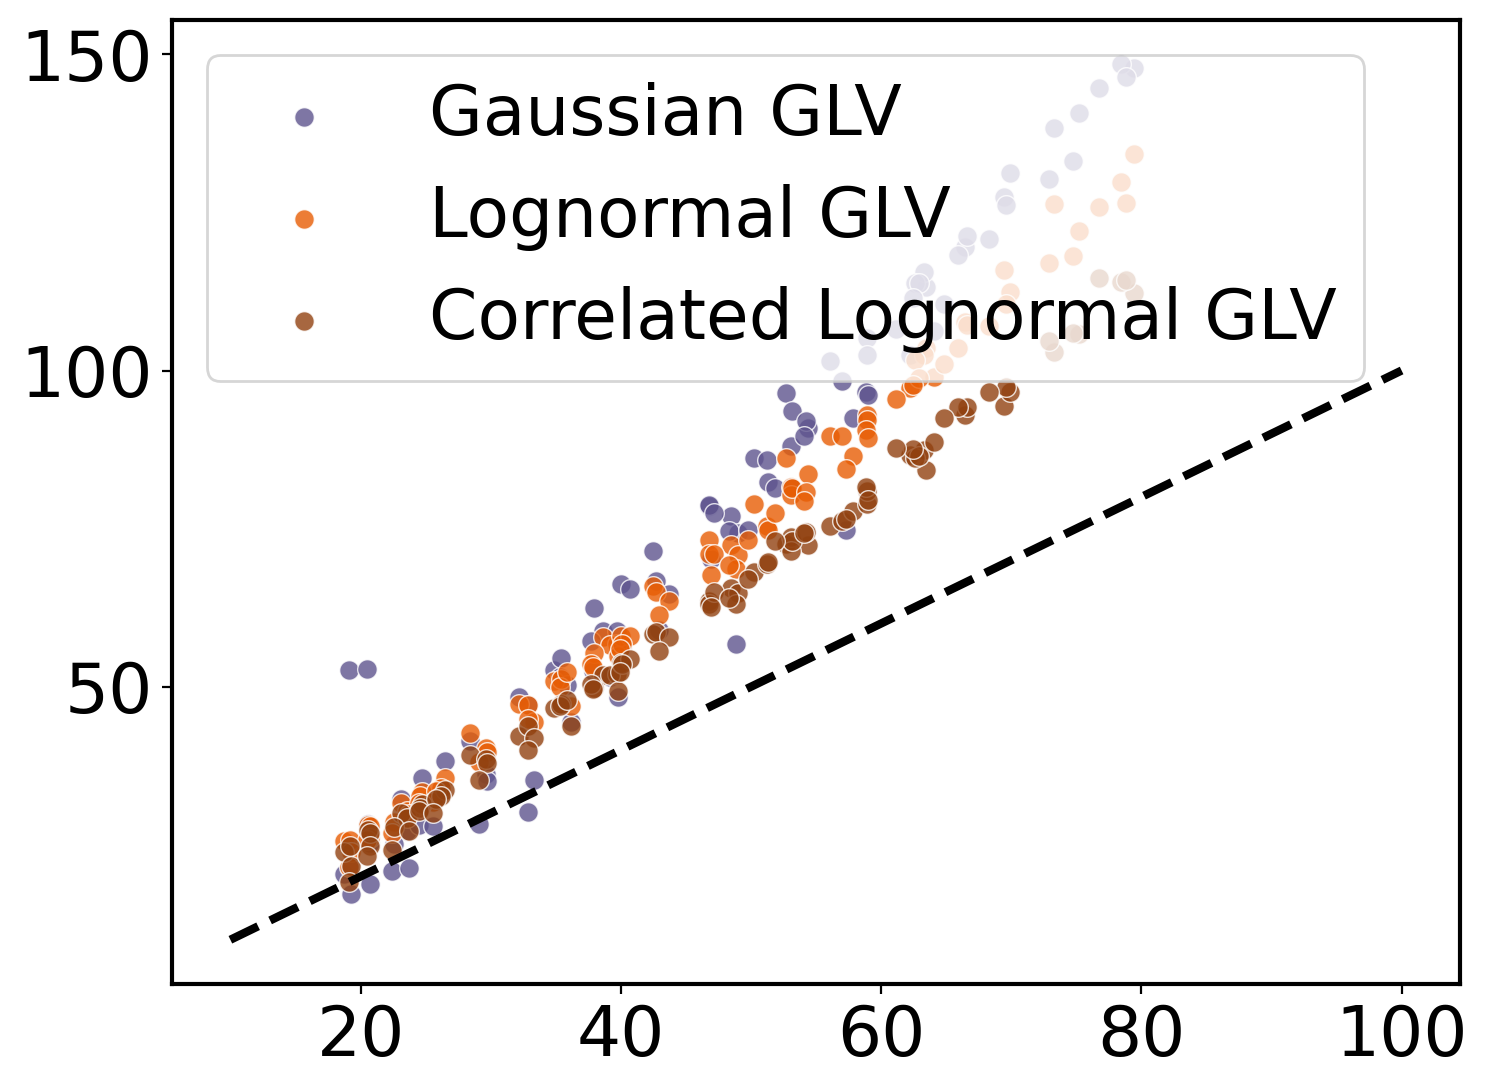

In [ ]:
plt.rcParams.update({'font.size': 25,"axes.linewidth": 1.5})
fig,ax = plt.subplots(figsize=(8, 6),dpi=200)

ax.scatter(high_supply_data["chemostat_richness"],high_supply_data["gaussian_richness"],s=50,color="#5e548e",label="Gaussian GLV",edgecolor="white",alpha=0.8,lw=0.5)
ax.scatter(high_supply_data["chemostat_richness"],high_supply_data["lognormal_richness"],s=50,color="#e85d04",label="Lognormal GLV",edgecolor="white",alpha=0.8,lw=0.5)
ax.scatter(high_supply_data["chemostat_richness"],high_supply_data["correlated_richness"],s=50,color="#914110fb",label="Correlated Lognormal GLV",edgecolor="white",alpha=0.8,lw=0.5)
ax.plot([10,100],[10,100],color="k",lw=3,ls="--")

plt.legend()
plt.tight_layout()
# plt.savefig("../figures/generated/fig3/predictability.svg",dpi=200,bbox_inches="tight")

plt.show()

In [41]:
face_colors =  ["#5e548e","#e85d04","#914110fb"]

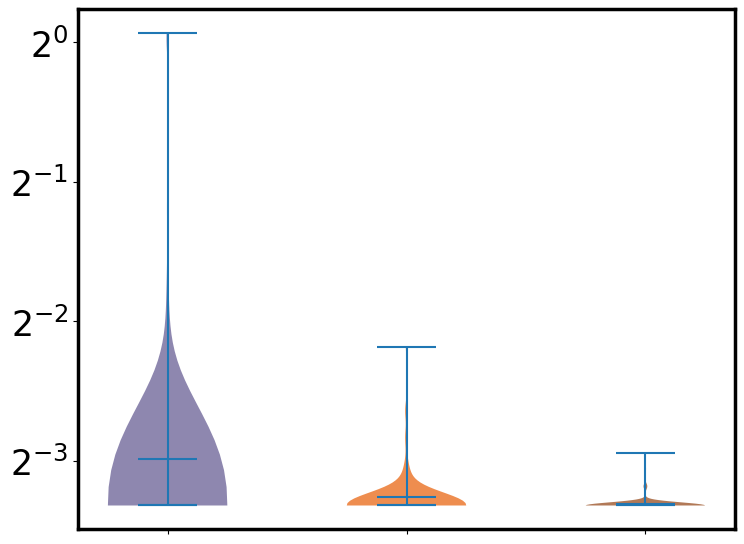

In [42]:
plt.rcParams.update({'font.size': 25,"axes.linewidth": 2.5})

fig,ax = plt.subplots(figsize=(8,6))
violins = ax.violinplot([0.1+high_supply_data["violin_gaussian"],
                         0.1+high_supply_data["violin_lognormal"],
                         0.1+high_supply_data["violin_correlated"]],
                        showmeans=True, showmedians=True, showextrema=True)
ax.set_xticks([1,2,3],["","", ""])
for i,pc in enumerate(violins['bodies']):
    pc.set_facecolor(face_colors[i])
    pc.set_alpha(0.7)
ax.set_yscale("log",base=2)
plt.tight_layout()
# plt.savefig("../figures/generated/fig3/stability_panel.svg",dpi=200,bbox_inches="tight")
plt.show()

In [43]:
np.mean(high_supply_data["violin_gaussian"]), np.mean(high_supply_data["violin_lognormal"]), np.mean(high_supply_data["violin_correlated"])

(0.0259, 0.004400000000000003, 0.0008000000000000007)

In [44]:
stats.friedmanchisquare(high_supply_data["violin_gaussian"],high_supply_data["violin_lognormal"],high_supply_data["violin_correlated"])

FriedmanchisquareResult(statistic=8.656249999999941, pvalue=0.013192259802176696)

In [45]:
difference_gaussian_richness = (high_supply_data["gaussian_richness"] - high_supply_data["chemostat_richness"])/ high_supply_data["chemostat_richness"]
difference_lognormal_richness = (high_supply_data["lognormal_richness"] - high_supply_data["chemostat_richness"])/ high_supply_data["chemostat_richness"]
difference_correlated_richness = (high_supply_data["correlated_richness"] - high_supply_data["chemostat_richness"])/ high_supply_data["chemostat_richness"]

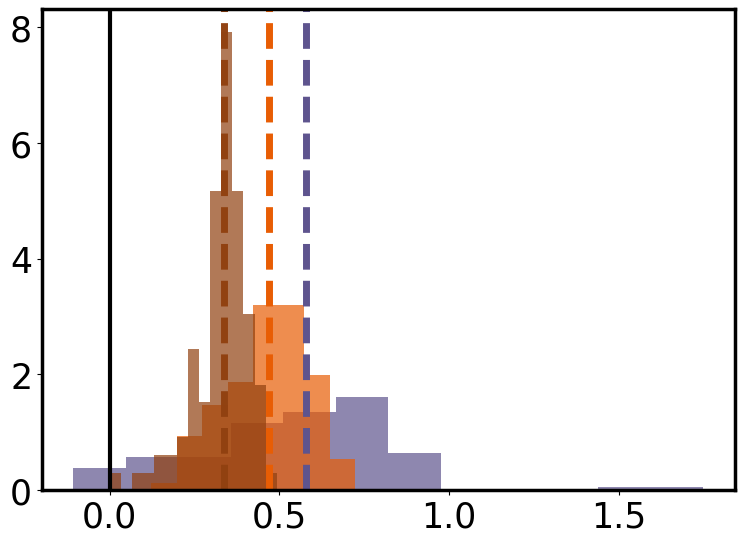

In [46]:
fig,ax = plt.subplots(figsize=(8,6))
plt.hist(difference_gaussian_richness,bins="auto",label="Gaussian GLV",color=face_colors[0],alpha=0.7,density=True)
plt.hist(difference_lognormal_richness,bins="auto",label="Lognormal GLV",color=face_colors[1],alpha=0.7,density=True)
plt.hist(difference_correlated_richness,bins="auto",label="Correlated Lognormal GLV",color=face_colors[2],alpha=0.7,density=True)

plt.axvline(np.nanmedian(difference_gaussian_richness),color=face_colors[0],ls="--",lw=5)
plt.axvline(np.nanmedian(difference_lognormal_richness),color=face_colors[1],ls="--",lw=5)
plt.axvline(np.nanmedian(difference_correlated_richness),color=face_colors[2],ls="--",lw=5)
plt.axvline(0,color="k",lw=3)
plt.tight_layout()
# plt.savefig("../figures/generated/fig3/richness_panel.svg",dpi=200,bbox_inches="tight")

plt.show()

In [47]:
absolute_gaussian_difference = (np.log(high_supply_data["gaussian_richness"]) - np.log(high_supply_data["chemostat_richness"]))
absolute_lognormal_difference = (np.log(high_supply_data["lognormal_richness"]) - np.log(high_supply_data["chemostat_richness"]))
absolute_correlated_difference = (np.log(high_supply_data["correlated_richness"]) - np.log(high_supply_data["chemostat_richness"]))

aic_gaussian = 2*2 + absolute_gaussian_difference.size * np.log(np.mean(absolute_gaussian_difference**2))
aic_lognormal = 2*5 + absolute_lognormal_difference.size * np.log(np.mean(absolute_lognormal_difference**2))
aic_correlated = 2*7 + absolute_correlated_difference.size * np.log(np.mean(absolute_correlated_difference**2))

print(aic_gaussian,aic_lognormal,aic_correlated)

delta_aic_lognormal = aic_lognormal - aic_gaussian
delta_aic_correlated = aic_correlated - aic_gaussian

print(delta_aic_lognormal, delta_aic_correlated)

-150.23181750968936 -179.0541357217228 -234.5228752413017
-28.822318212033423 -84.29105773161234


In [48]:
np.sqrt(np.mean(absolute_gaussian_difference**2)), np.sqrt(np.mean(absolute_lognormal_difference**2)), np.sqrt(np.mean(absolute_correlated_difference**2))

(0.46247670653415845, 0.3885743778936955, 0.2886286468290562)

In [49]:
np.std(absolute_gaussian_difference), np.std(absolute_lognormal_difference), np.std(absolute_correlated_difference)

(0.2095452745463536, 0.08537631898262134, 0.06381080402344326)

# Figure 4

In [50]:
import scipy.stats as stats

In [51]:
def compute_shannon(abundances_original):
    abundances = abundances_original.copy()
    abundances[abundances <= 0] = 1e-30
    return -np.sum(abundances/np.sum(abundances) * np.log(abundances/np.sum(abundances)))

In [52]:
def analyze_interactions(non_diag_resc):
    pos_frac = np.where(non_diag_resc < 0 )[0].size / non_diag_resc.size
    if(pos_frac > 0):
        pos_inters =  -non_diag_resc[non_diag_resc < 0]
        log_pos_mean,log_pos_std = np.mean(np.log(pos_inters)), np.std(np.log(pos_inters))
    else:
        log_pos_mean,log_pos_std = 0,0
    neg_inters = non_diag_resc[non_diag_resc > 0]
    log_neg_mean,log_neg_std = np.mean(np.log(neg_inters)), np.std(np.log(neg_inters))
    return log_pos_mean,log_pos_std,log_neg_mean,log_neg_std,pos_frac

### Duckweed

In [53]:
drop_one_pops = np.load("../data/figures/fig4/duckweed/drop_one_communities.npy",allow_pickle=True)
inters_chain = np.load("../data/figures/fig4/duckweed/interaction_chains.npy",allow_pickle=True)

In [54]:
mean_inters = np.mean(inters_chain,axis=0)
inter_matrix = np.reshape(np.array(mean_inters),(7,7)).astype(float)
rescaled_inter_matrix = inter_matrix / np.diag(inter_matrix)
hist,edges = np.histogram(-rescaled_inter_matrix[np.where(rescaled_inter_matrix != 1)],bins="auto",density=True)

In [55]:
lg_params = analyze_interactions(rescaled_inter_matrix[~np.eye(rescaled_inter_matrix.shape[0],dtype=bool)])

pos_lg_xrange = np.linspace(0.05,2.5,100)
pos_lg_dist = 1/(lg_params[1]*np.sqrt(2*np.pi))*np.exp(-((np.log(pos_lg_xrange)-lg_params[0])**2)/(2*lg_params[1]**2))/pos_lg_xrange

neg_lg_xrange = np.linspace(0.04,2.5,100)
neg_lg_dist = 1/(lg_params[3]*np.sqrt(2*np.pi))*np.exp(-((np.log(neg_lg_xrange)-lg_params[2])**2)/(2*lg_params[3]**2))/neg_lg_xrange

gaussian_range = np.linspace(-2.5,2.5,1000)
gaussian_mean,gaussian_sd = np.mean(-rescaled_inter_matrix[~np.eye(rescaled_inter_matrix.shape[0],dtype=bool)]), np.std(-rescaled_inter_matrix[~np.eye(rescaled_inter_matrix.shape[0],dtype=bool)])
gaussian_dist = 1/(gaussian_sd*np.sqrt(2*np.pi))*np.exp(-((gaussian_range - gaussian_mean)**2)/(2*gaussian_sd**2))  

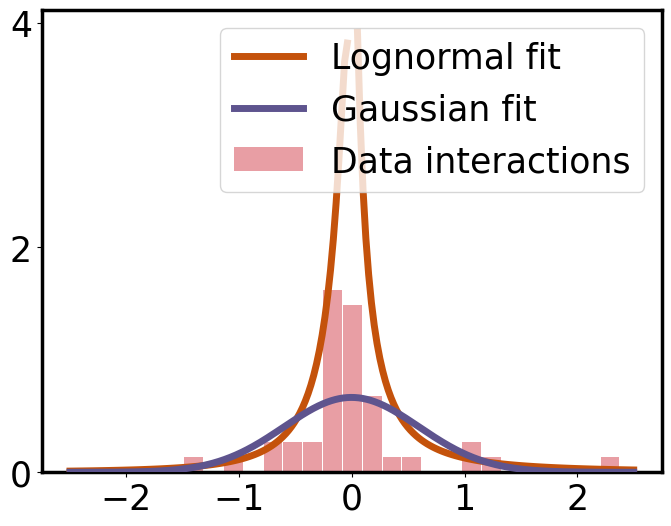

In [57]:
fig,ax = plt.subplots(figsize=(8,6))
ax.bar(edges[:-1],hist, width=np.diff(edges)*0.95,linewidth=1,color="#dd6b74",alpha=0.65,align='edge',label="Data interactions")
ax.tick_params(axis='both', which='major', labelsize=20,zorder=3)
ax.plot(pos_lg_xrange,pos_lg_dist,lw=5,color="#c4520b",zorder=4,label="Lognormal fit")
ax.plot(-neg_lg_xrange,neg_lg_dist,lw=5,color="#c4520b",zorder=4)
ax.plot(gaussian_range,gaussian_dist,lw=5,color="#5e548e",zorder=5,label="Gaussian fit")


ax.set_yticks([0,2,4])
ax.set_xticks([-2,-1,0,1,2])
ax.tick_params(axis='y', labelsize=25)
ax.tick_params(axis='x', labelsize=25)
ax.legend()

# plt.savefig("../figures/generated/fig4/duckweed/interaction_distribution.svg",dpi=300,bbox_inches="tight")
plt.show()

In [58]:
drop_one_diversities = np.zeros(drop_one_pops.shape[0])
for i in range(drop_one_pops.shape[0]):
    drop_one_diversities[i] = compute_shannon(drop_one_pops[i])

In [59]:
gaussian_diversities_doo = np.load("../data/figures/fig4/duckweed/gaussian_diversities_doo.npy")
lognormal_diversities_doo = np.load("../data/figures/fig4/duckweed/lognormal_diversities_doo.npy")

Mann Whitney p-values:  [0.003945453883051598, 0.7100189428085295]


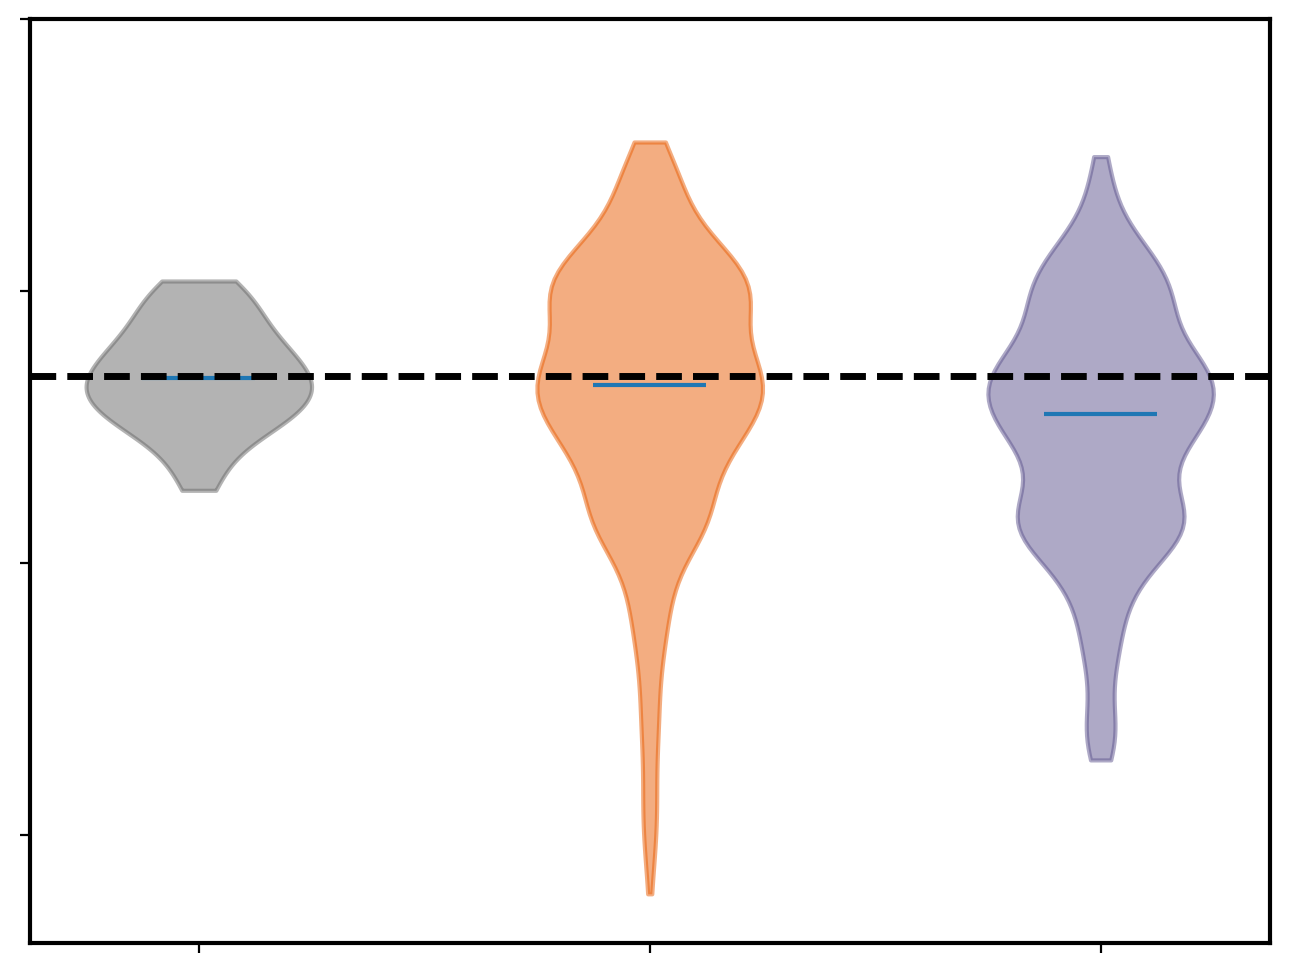

In [62]:
glv_diversities = [gaussian_diversities_doo,lognormal_diversities_doo]
mannwhitney_full = []

for i in range(2):
    mann_whitney = stats.mannwhitneyu(glv_diversities[i],(drop_one_diversities),alternative="two-sided")
    mannwhitney_full.append(mann_whitney.pvalue)

print("Mann Whitney p-values: ",mannwhitney_full)

plt.rcParams.update({'font.size': 25,"axes.linewidth": 1.5})
fig,ax = plt.subplots(figsize=(8,6),dpi=200)
medianprops = dict(linewidth=2, color="#1d2d44",solid_capstyle="butt")
violins = ax.violinplot([drop_one_diversities,lognormal_diversities_doo,gaussian_diversities_doo],showmeans=False, showmedians=True, showextrema=False, widths=0.5)
ax.axhline(np.mean(drop_one_diversities),color="k",linestyle="--",label="Observed",lw=2.5)
ax.set_xticks([1,2,3],["","",""])
ax.set_yticklabels([])
violin_colors = ["#696969","#e85d04","#5e548e"]
for i,violin in enumerate(violins["bodies"]):
    violin.set_facecolor(violin_colors[i])
    violin.set_edgecolor(violin_colors[i])
    violin.set_linewidth(1.5)
    violin.set_alpha(0.5)
ax.set_ylim(0.3,2.)
ax.set_yticks([0.5,1,1.5,2])
# plt.savefig("../figures/generated/fig4/duckweed/diversity_violinplot.svg",bbox_inches="tight")
plt.show()

### Gut

In [63]:
drop_one_pops = np.load("../data/figures/fig4/gut/drop_one_out_pops.npy",allow_pickle=True)
rescaled_interactions = np.load("../data/figures/fig4/gut/eo_interactions.npy",allow_pickle=True)

In [64]:
lg_params = analyze_interactions(rescaled_inter_matrix[~np.eye(rescaled_inter_matrix.shape[0],dtype=bool)])

neg_lg_range = np.linspace(0.001,1,1000)
neg_lg_dist = 1/(lg_params[3]*np.sqrt(2*np.pi))*np.exp(-((np.log(neg_lg_range)-lg_params[2])**2)/(2*lg_params[3]**2))/neg_lg_range

gaussian_mean,gaussian_sd = np.mean(-rescaled_interactions[~np.eye(rescaled_interactions.shape[0],dtype=bool)]), np.std(-rescaled_interactions[~np.eye(rescaled_interactions.shape[0],dtype=bool)])
gaussian_range = np.linspace(-1,0,1000)
gaussian_dist = 1/(gaussian_sd*np.sqrt(2*np.pi))*np.exp(-((gaussian_range - gaussian_mean)**2)/(2*gaussian_sd**2))
trunc_gaussian = 1/(np.sum(gaussian_dist)*np.diff(gaussian_range)[0]) * gaussian_dist

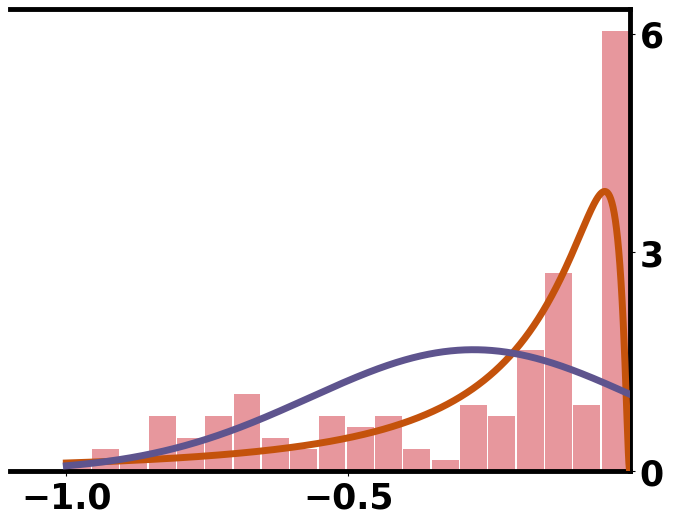

In [65]:
plt.rcParams.update({'font.size': 25,"axes.linewidth": 3.5,'font.weight': 'bold'})

hist,edges = np.histogram(-(rescaled_interactions[np.where(rescaled_interactions != 1)]),bins=20,density=True)
fig,ax = plt.subplots(figsize=(8,6))

ax.spines[["right"]].set_visible(True)
ax.spines[["left"]].set_visible(False)


ax.bar(edges[:-1],hist, width=np.diff(edges)*0.95, align='edge', alpha=0.7, color="#dd6b74")
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xlim(-1.1,0)
ax.yaxis.tick_right()
ax.plot(-neg_lg_range,neg_lg_dist,lw=5,color="#c4520b",zorder=4)
ax.plot(gaussian_range,trunc_gaussian,lw=5,color="#5e548e",zorder=5)

ax.set_yticks([0,3,6])
ax.set_xticks([-0.5,-1])
ax.tick_params(axis='y', labelsize=25)
ax.tick_params(axis='x', labelsize=25)
# plt.savefig("../figures/generated/fig4/gut/interaction_distribution.svg",dpi=300,bbox_inches="tight")
plt.show()

In [66]:
gaussian_diversities =  np.load("../data/figures/fig4/gut/gaussian_diversities.npy")
lognormal_diversities =  np.load("../data/figures/fig4/gut/lognormal_diversities.npy")

In [67]:
drop_one_diversities = np.zeros(drop_one_pops.shape[0])
for i in range(drop_one_pops.shape[0]):
    drop_one_diversities[i] = compute_shannon(drop_one_pops[i])

Mann Whitney p-values:  [0.000177169883864942, 0.14473846852986444]


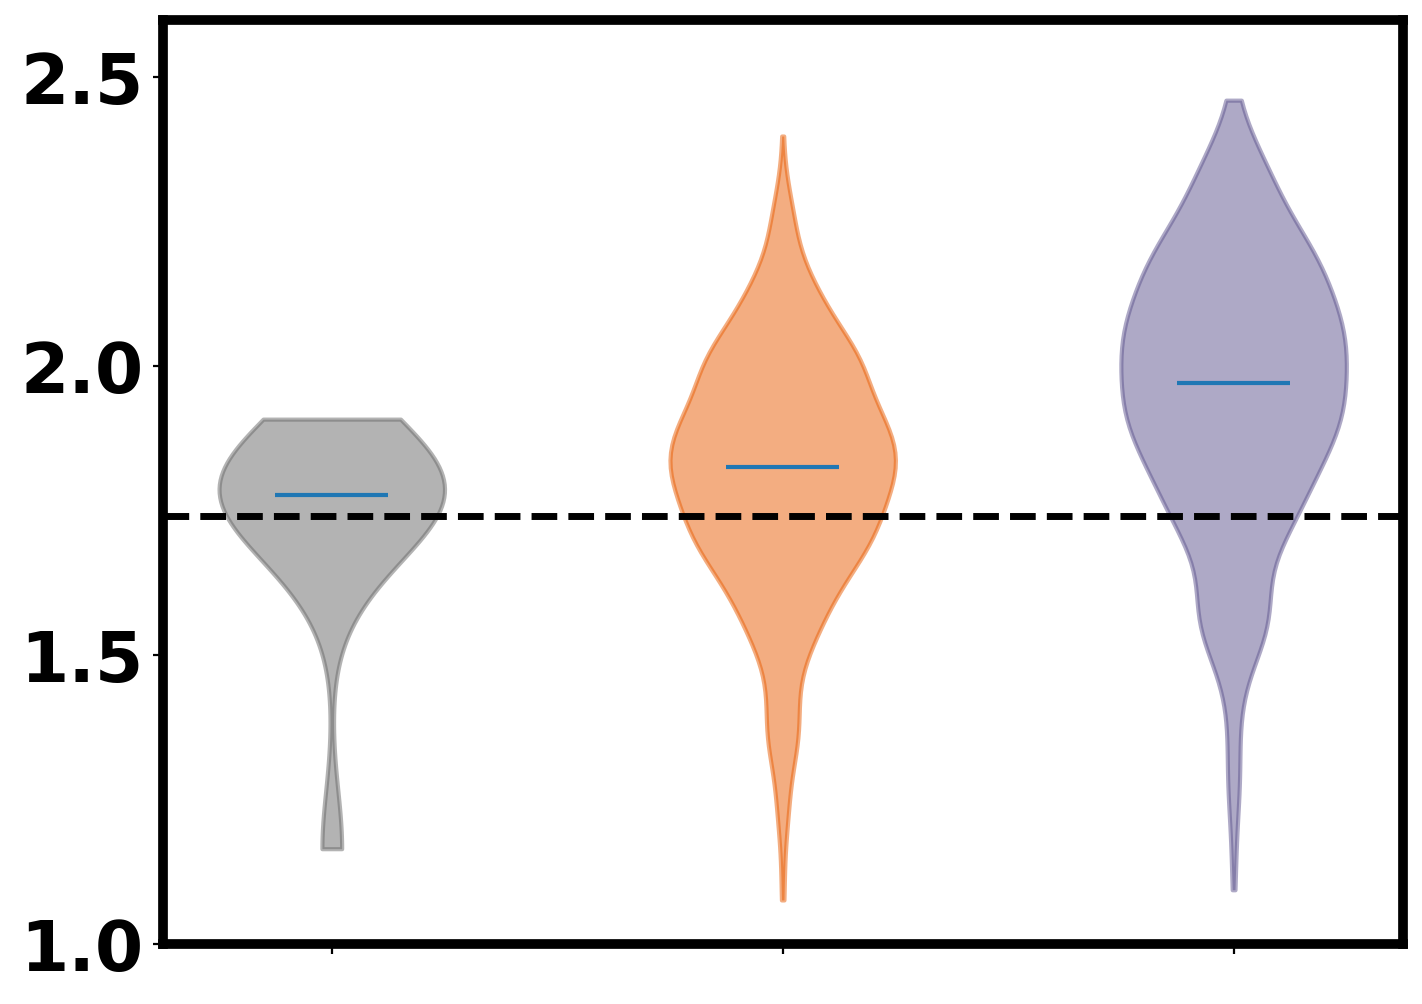

In [68]:
glv_diversities = [gaussian_diversities,lognormal_diversities]
mannwhitney_full = []

for i in range(2):
    mann_whitney = stats.mannwhitneyu(glv_diversities[i],(drop_one_diversities),alternative="two-sided")
    mannwhitney_full.append(mann_whitney.pvalue)

print("Mann Whitney p-values: ",mannwhitney_full)

fig,ax = plt.subplots(figsize=(8,6),dpi=200)
medianprops = dict(linewidth=1, color="#1d2d44",solid_capstyle="butt")
violins = ax.violinplot([drop_one_diversities,lognormal_diversities,gaussian_diversities],showmeans=False, showmedians=True, showextrema=False, widths=0.5)
ax.axhline(np.mean(drop_one_diversities),color="k",linestyle="--",label="Observed",lw=2.5)
ax.set_xticks([1,2,3],["","",""])
# ax.set_yticklabels([],fontsize=25)
violin_colors = ["#696969","#e85d04","#5e548e"]
for i,violin in enumerate(violins["bodies"]):
    violin.set_facecolor(violin_colors[i])
    violin.set_edgecolor(violin_colors[i])
    violin.set_linewidth(1.5)
    violin.set_alpha(0.5)
ax.set_ylim(1,2.6)
ax.set_yticks([1,1.5,2,2.5])
# plt.savefig("../figures/generated/fig4/gut/diversity_violinplot.svg",bbox_inches="tight")
plt.show()

In [69]:
def compute_difference(cr_diversities,glv_diversities):
    difference = np.zeros(len(cr_diversities)*len(glv_diversities))
    for i in range(len(cr_diversities)):
        for j in range(len(glv_diversities)):
            difference[i*len(glv_diversities) + j] = cr_diversities[i] - glv_diversities[j]
    return difference

In [70]:
duckweed_pops = np.load("../data/figures/fig4/duckweed/drop_one_communities.npy",allow_pickle=True)
gut_pops = np.load("../data/figures/fig4/gut/drop_one_out_pops.npy",allow_pickle=True)

duckweed_gaussian = np.load("../data/figures/fig4/duckweed/gaussian_diversities_doo.npy")
gut_gaussian = np.load("../data/figures/fig4/gut/gaussian_diversities.npy")
duckweed_lognormal = np.load("../data/figures/fig4/duckweed/lognormal_diversities_doo.npy")
gut_lognormal = np.load("../data/figures/fig4/gut/lognormal_diversities.npy")

duckweed_diversities = np.zeros(duckweed_pops.shape[0])
for i in range(duckweed_pops.shape[0]):
    duckweed_diversities[i] = compute_shannon(duckweed_pops[i])
gut_diversities = np.zeros(gut_pops.shape[0])
for i in range(gut_pops.shape[0]):
    gut_diversities[i] = compute_shannon(gut_pops[i])

In [71]:
difference_duckweed_gaussian = compute_difference(duckweed_diversities,duckweed_gaussian)
difference_duckweed_lognormal = compute_difference(duckweed_diversities,duckweed_lognormal)
difference_gut_gaussian = compute_difference(gut_diversities,gut_gaussian)
difference_gut_lognormal = compute_difference(gut_diversities,gut_lognormal)

In [72]:
np.mean(np.abs(difference_gut_gaussian)), np.mean(np.abs(difference_gut_lognormal))

(0.287572665328063, 0.2099131921953169)

In [73]:
rmse_gut_lognormal = np.sqrt(np.mean(difference_gut_lognormal**2))
cv_rmse_lognormal = rmse_gut_lognormal / np.mean(gut_diversities)
print("Gut lognormal CV-RMSE: ",cv_rmse_lognormal)
print("Welch's t-test p-value (gut lognormal): ",stats.ttest_ind(gut_diversities,gut_lognormal,alternative="two-sided",equal_var=False).pvalue)

Gut lognormal CV-RMSE:  0.16106417922482605
Welch's t-test p-value (gut lognormal):  0.1204859608610976


In [74]:
print("Duckweed difference")
print(stats.mannwhitneyu(np.abs(difference_duckweed_gaussian),np.abs(difference_duckweed_lognormal),alternative="greater"))
print("Gut difference")
print(stats.mannwhitneyu(np.abs(difference_gut_gaussian),np.abs(difference_gut_lognormal),alternative="greater"))

Duckweed difference
MannwhitneyuResult(statistic=666514629.0, pvalue=0.013399110704065043)
Gut difference
MannwhitneyuResult(statistic=138930804.0, pvalue=2.3997185314988616e-272)


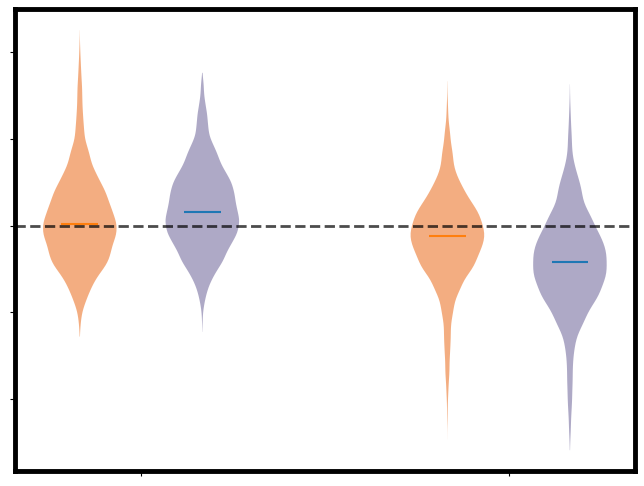

In [ ]:
fig,ax = plt.subplots(figsize=(8,6))

violin_gaussian = ax.violinplot([difference_duckweed_gaussian,difference_gut_gaussian],positions=[2,5],showmeans=False,showextrema=False,showmedians=True,widths=0.6)
violin_lognormal = ax.violinplot([difference_duckweed_lognormal,difference_gut_lognormal],positions=[1,4],showmeans=False,showextrema=False,showmedians=True,widths=0.6)

for pc in violin_lognormal["bodies"]:
    pc.set_facecolor("#e85d04")
    pc.set_alpha(0.5)
for pc in violin_gaussian["bodies"]:
    pc.set_facecolor("#5e548e")
    pc.set_alpha(0.5)

ax.axhline(0,color="black",linestyle="--",alpha=0.7,lw=2)
ax.set_yticklabels([])

ax.set_xticks([1.5,4.5],[])
# plt.savefig("../figures/generated/fig4/diversity_difference_violin.svg",dpi=300,bbox_inches="tight")
plt.show()